# Assignment 2 - Poject 7 Mixed Precision Training Strategy for VAE and VQ-VAE


## Description
Variational Autoencoders (VAE) and Vector Quantized Variational Autoencoders (VQ-VAE) are powerful generative models used in the field of deep learning for unsupervised learning tasks. This project aims to compare the performance of these models on three benchmark datasets: CIFAR-10, MNIST, and Fashion-MNIST. A key aspect of this comparison will be the use of normal and mixed precision training approaches, which have implications for training efficiency and model accuracy.

### Objectives

 - Implement VAE and VQ-VAE models in a deep learning framework
 - Train and evaluate these models on CIFAR-10, MNIST, and Fashion-MNIST datasets
 - Compare the performance of each model using normal and mixed precision training methods.
- Analyze the effects of precision training on the efficiency and accuracy of the models.

### notes on approach - A

- implimentation
    - VAE and VQ-VAE
- train both on each dataset
- comparison
    - mixed vs normal precision training
- analysis 
    - generation quality and reconstruction quality
    - training efficency
    - accuacay and preformance trade-offs
    

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import os
import time
import pathlib as Path
import sys
import pandas as pd
from tqdm import tqdm


import torchvision.utils as vutils


### Import SRC files 

In [12]:
from src.config import *
import src.datafunctions as DF
import src.vq_vae as VQ 


In [13]:
#Make sure GPU torch is instaled and available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
#Check if GPU is available and set device accordingly
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
GPU: Quadro T1000 with Max-Q Design


In [14]:
def show_batch(images, n=8, title="Batch"):
    images = images[:n].cpu()
    grid = vutils.make_grid(images, nrow=n, padding=2)
    plt.figure(figsize=(n * 1.5, 2))
    plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray" if images.shape[1] == 1 else None)
    plt.title(title)
    plt.axis("off")
    plt.show()

In [32]:
mnist_train, mnist_test, mnist_in_channels, mnist_input_size = DF.get_dataloaders(
    data_dir=DATA_DIR,
    dataset_name="mnist",
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
)
fashion_mnist_train, fashion_mnist_test, fashion_mnist_in_channels, fashion_mnist_input_size = DF.get_dataloaders(
    data_dir=DATA_DIR,
    dataset_name="fashion-mnist",
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
)
cifar10_train, cifar10_test, cifar10_in_channels, cifar10_input_size = DF.get_dataloaders(
    data_dir=DATA_DIR,
    dataset_name="cifar10",
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
)

torch.Size([128, 1, 28, 28]) torch.Size([128])


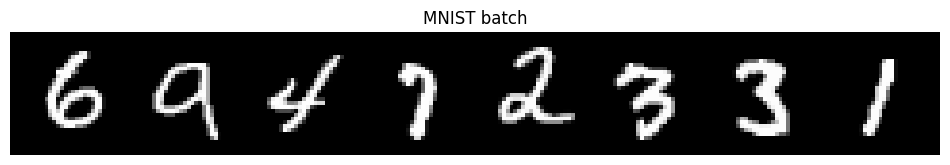

torch.Size([128, 1, 28, 28]) torch.Size([128])


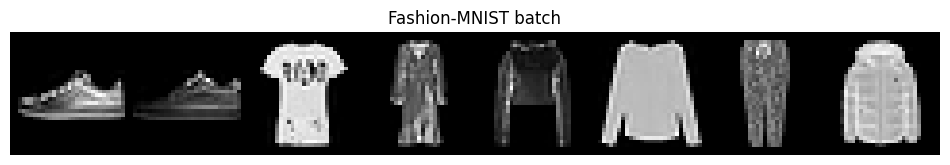

torch.Size([128, 3, 32, 32]) torch.Size([128])


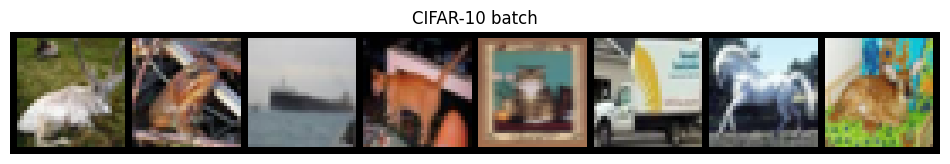

In [33]:
mnist_images, labels = next(iter(mnist_train))
fashion_mnist_images, labels1 = next(iter(fashion_mnist_train))
cifar10_images, labels2 = next(iter(cifar10_train))

print(mnist_images.shape, labels.shape)
show_batch(mnist_images, title="MNIST batch")
print(fashion_mnist_images.shape, labels1.shape)
show_batch(fashion_mnist_images, title="Fashion-MNIST batch")
print(cifar10_images.shape, labels2.shape)
show_batch(cifar10_images, title="CIFAR-10 batch")

## VQ-VAE dev section

Add complexity, by introducing up- down- and res- blocks that can be tuned 

In [17]:
# The number of code book embeddings
code_book_size = 32

hidden_channels = 10

vq_nepoch = dev_EPOCHS


In [18]:
vae_net = VQ.VQVAE(in_channels=mnist_in_channels, hidden_channels=hidden_channels,
                   latent_dim=LATENT_DIM, code_book_size=code_book_size, commitment_cost=0.25).to(device)

optimizer = torch.optim.Adam(vae_net.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=5, eta_min=0)

history = VQ.train_vqvae(
    model=vae_net,
    train_loader=mnist_train,
    test_loader=mnist_test,
    device=device,
    epochs=vq_nepoch,
    use_mixed_precision=False,
)

KeyboardInterrupt: 

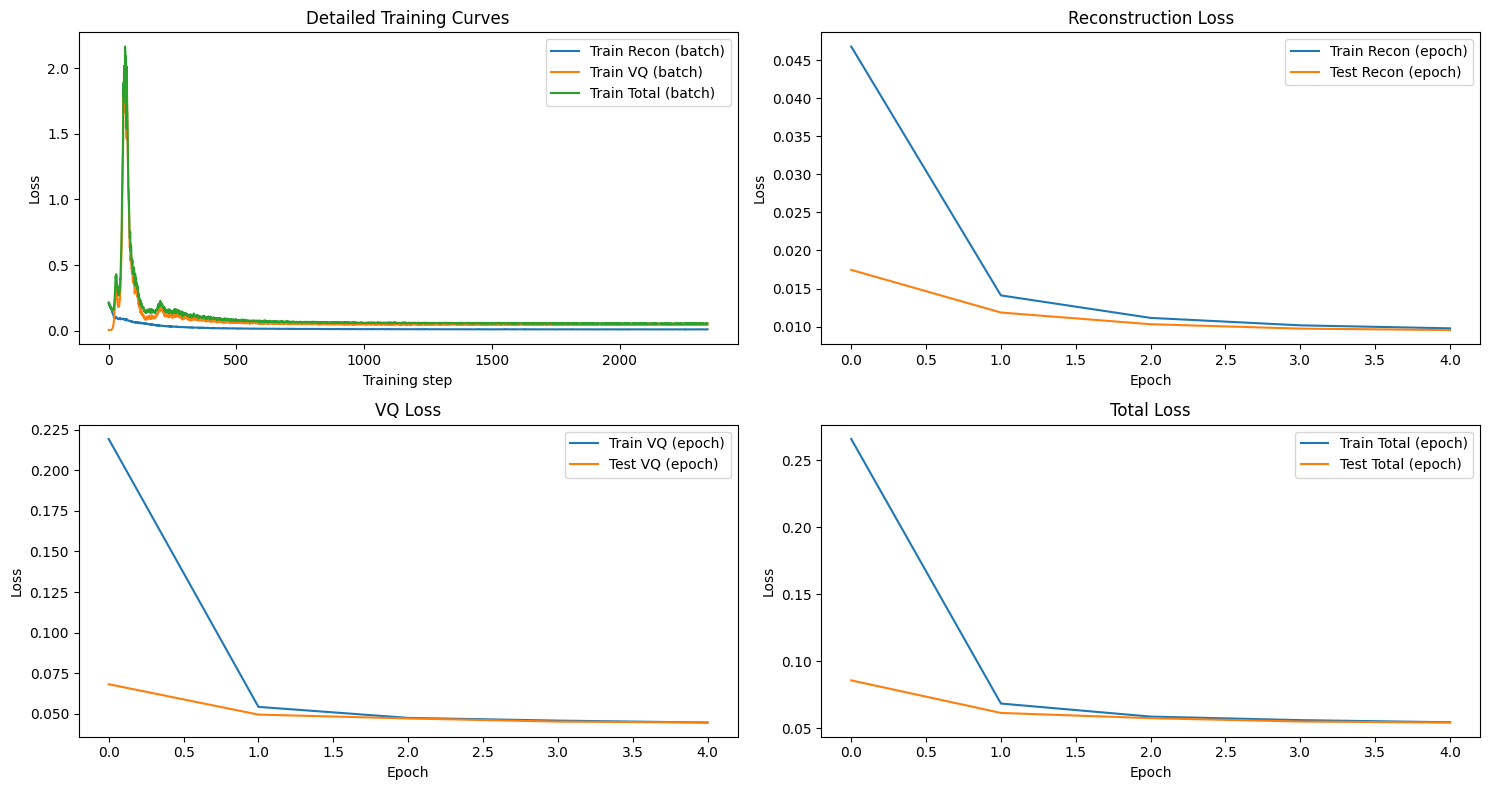

Final Metrics
Train Recon Loss: 0.009781
Train VQ Loss:    0.044683
Train Total Loss: 0.054464
Test Recon Loss:  0.009557
Test VQ Loss:     0.044691
Test Total Loss:  0.054248

Final batch reconstruction MSE: 0.007221
Batch VQ loss: 0.033740
Quantized latent shape: torch.Size([8, 64, 7, 7])
Encoding indices shape: torch.Size([8, 7, 7])


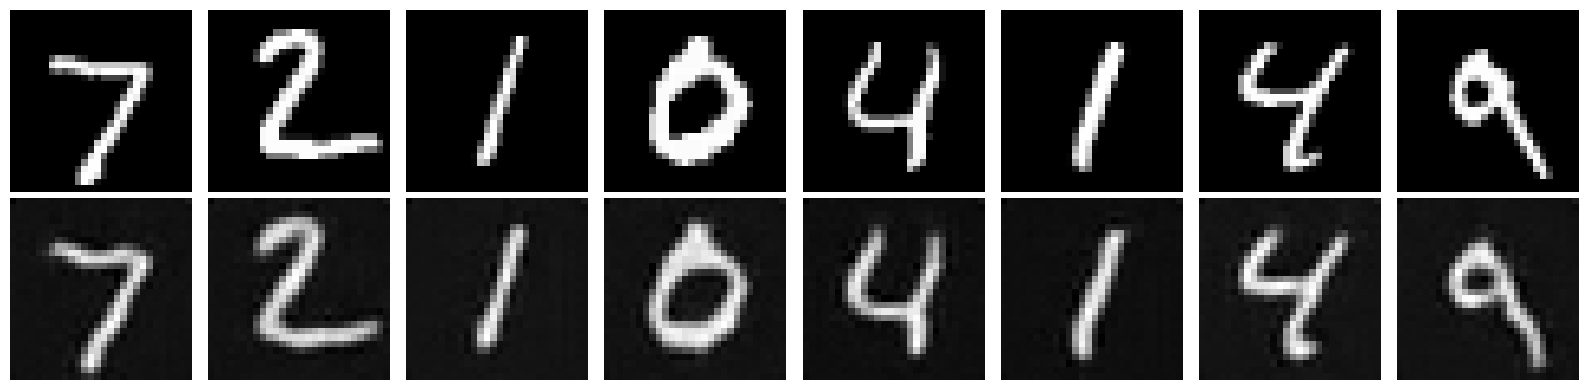

In [ ]:
VQ.show_vqvae_results(history, mnist_test, device, num_images=8)


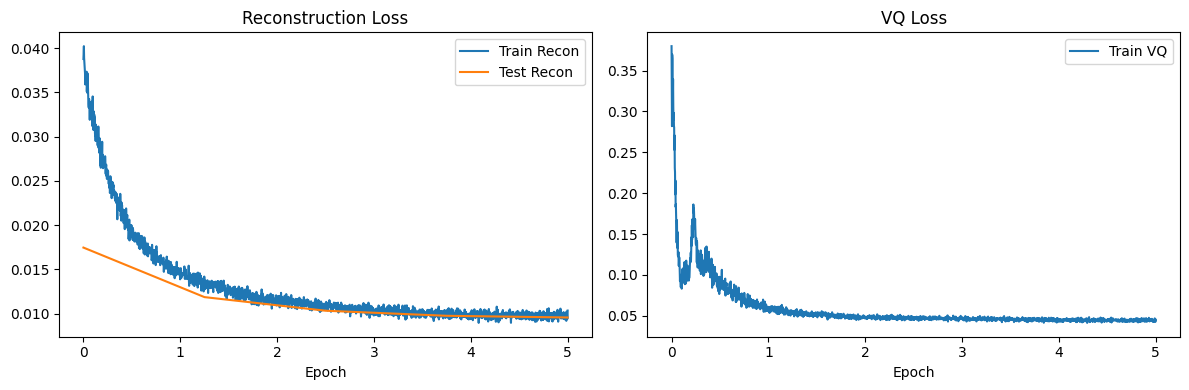

In [ ]:
VQ.show_vqvae_curves(history, vq_nepoch)

# VAE implementation

iets


In [66]:
class VAE(nn.Module):
    """
    Standard Variational Autoencoder using Linear (Fully Connected) layers.
    """
    def __init__(self, input_dim=784, hidden_channels=400, latent_dim=32):
        super(VAE, self).__init__()
        
        self.input_dim = input_dim
        self.hidden_channels = hidden_channels
        self.latent_dim = latent_dim

        # Encoder
        self.fc1 = nn.Linear(input_dim, hidden_channels) #input to hidden
        self.enc_fc2 = nn.Linear(hidden_channels, hidden_channels) #hidden to hidden

        # the encoder outputs the mean and log variance for the latent space
        self.enc_mean = nn.Linear(hidden_channels, latent_dim) #hidden to mean
        self.enc_logvar = nn.Linear(hidden_channels, latent_dim) #hidden to logvar

        # Decoder
        self.dec_fc1 = nn.Linear(latent_dim, hidden_channels) #latent to hidden
        self.dec_fc2 = nn.Linear(hidden_channels, hidden_channels) #hidden to hidden
        self.dec_output = nn.Linear(hidden_channels, input_dim) #hidden to output

        self.leaky_relu = nn.LeakyReLU(0.2) #LeakyReLU activation function


    def encode(self, x):
        """Encodes the input into the latent space, returning the mean and log variance."""
        h = self.leaky_relu(self.fc1(x))
        h = self.leaky_relu(self.enc_fc2(h))
        mean = self.enc_mean(h)
        logvar = self.enc_logvar(h)
        return mean, logvar
    
    def reparameterize(self, mean, logvar):
        """Applies reparameterization trick z = mean + std * eps, where eps ~ N(0, 1)
        This allows backpropagation through the stochastic sampling process."""
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mean + std * eps
    

    def decode(self, z):
        """Decodes the latent variable back to the input space."""
        h = self.leaky_relu(self.dec_fc1(z))
        h = self.leaky_relu(self.dec_fc2(h))
        x_hat = torch.sigmoid(self.dec_output(h)) #sigmoid to get output in [0, 1]
        return x_hat
    
    def forward(self, x):
        # Flatten the input image to a vector
        BATCH_SIZE, C, H, W = x.size() #C = channels, H = height, W = width
        x_flat = x.view(BATCH_SIZE, -1) # Flatten the image to a vector

        # Encode the input to get mean and log variance
        mean, logvar = self.encode(x_flat)

        # Sample from the distribution using the reparameterization trick
        z = self.reparameterize(mean, logvar)

        # Decode the latent variable to reconstruct the input
        x_hat = self.decode(z)

        #reshape the output back to the original image shape
        x_hat = x_hat.view(BATCH_SIZE, C, H, W)
        return x_hat, mean, logvar


class ConvVAE(nn.Module):
    """
    Convolutional Variational Autoencoder for complex image datasets.
    """
    def __init__(self, in_channels, input_size, latent_dim=128, dataset_name="mnist"):
        super(ConvVAE, self).__init__()
        
        self.latent_dim = latent_dim
        self.dataset_name = dataset_name.lower()

        # ==========================================
        # 1. Input Size Type-Check
        # ==========================================
        # If your dataloader returns an int (e.g., 28), convert it to (28, 28)
        if isinstance(input_size, int):
            self.img_height = input_size
            self.img_width = input_size
        else:
            self.img_height = input_size[0]
            self.img_width = input_size[1]


        # ==========================================
        # ENCODER (Conv2d downsamples the image)
        # ==========================================
        # Formula for output size: [(W - Kernel + 2*Pad) / Stride] + 1
        self.enc_conv1 = nn.Conv2d(in_channels, 32, kernel_size=3, stride=2, padding=1)
        self.enc_conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1)
        self.leaky_relu = nn.LeakyReLU(0.2)
        
        # --- Dynamic Dimension Calculation ---
        # We pass a dummy tensor of the correct shape through the conv layers 
        # to figure out exactly how many features we need to flatten!
        dummy_x = torch.zeros(1, in_channels, self.img_height, self.img_width)
        dummy_out = self.enc_conv2(self.enc_conv1(dummy_x))
        
        # Save the shape before flattening so the decoder knows how to unflatten it later
        self.conv_shape = dummy_out.shape[1:] 
        self.flattened_size = dummy_out.numel()
        # -------------------------------------
        
        # Latent space mappings
        self.enc_mean = nn.Linear(self.flattened_size, latent_dim)
        self.enc_logvar = nn.Linear(self.flattened_size, latent_dim)
        
        # ==========================================
        # DECODER (ConvTranspose2d upsamples the image)
        # ==========================================
        self.dec_fc = nn.Linear(latent_dim, self.flattened_size)
        self.dec_conv1 = nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1)
        self.dec_conv2 = nn.ConvTranspose2d(32, in_channels, kernel_size=3, stride=2, padding=1, output_padding=1)

    def encode(self, x):
        h = self.leaky_relu(self.enc_conv1(x))
        h = self.leaky_relu(self.enc_conv2(h))
        
        # Flatten for the linear layer
        h_flat = h.view(h.size(0), -1)
        mean = self.enc_mean(h_flat)
        logvar = self.enc_logvar(h_flat)
        return mean, logvar
        
    def reparameterize(self, mean, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mean + std * eps
        
    def decode(self, z):
        # 1. Map latent vector back to the flattened spatial size
        h = self.leaky_relu(self.dec_fc(z))
        
        # 2. Reshape back to 3D tensor (Channels, Height, Width)
        h = h.view(h.size(0), *self.conv_shape)
        
        # 3. Upsample back to original image size
        h = self.leaky_relu(self.dec_conv1(h))
        
        # No ReLU on the final output, use Sigmoid (for MNIST/Fashion) or Tanh (if CIFAR is normalized -1 to 1)
        if self.dataset_name == "cifar10":
            x_hat = torch.tanh(self.dec_conv2(h))
        else:
            x_hat = torch.sigmoid(self.dec_conv2(h))
        return x_hat

    def forward(self, x):
        # Notice we NO LONGER flatten the input 'x' here! It stays as a 2D image.
        mean, logvar = self.encode(x)
        z = self.reparameterize(mean, logvar)
        x_hat = self.decode(z)
        
        return x_hat, mean, logvar

In [68]:
# Loss function for VAE: Reconstruction loss + KL divergence
def vae_loss(reconstructed_x, x_orig, mean, logvar, dataset_name):
    """
    Computes the VAE loss, dynamically selecting the reconstruction 
    loss based on the dataset properties.
    """
    # 1. Reconstruction Loss
    if dataset_name.lower() == "cifar10":
        # MSE is standard for continuous RGB data
        recon_loss = F.mse_loss(reconstructed_x, x_orig, reduction='sum')
    else:
        # BCE is standard for normalized grayscale data [0, 1] (MNIST/Fashion-MNIST)
        recon_loss = F.binary_cross_entropy(reconstructed_x, x_orig, reduction='sum')

    # 2. KL Divergence
    KLD = -0.5 * torch.sum(1 + logvar - mean.pow(2) - logvar.exp())
    
    return recon_loss + KLD, recon_loss, KLD

def train_vae(model, train_loader, epochs, optimizer, device, dataset_name, use_mixed_precision=False):
    """Trains the VAE model and returns the training history."""

    model.train()
    history = {"train_loss": [], "bce_loss": [], "kld_loss": []}

    # 1. Initialize the gradient scaler for mixed precision
    # If use_mixed_precision is False, the scaler just does standard FP32 operations
    scaler = torch.amp.GradScaler(device=device.type, enabled=use_mixed_precision)

    for epoch in range(epochs):
        train_loss = 0
        train_recon = 0
        train_kld = 0
        for batch_idx, (data, _) in enumerate(train_loader):
            data = data.to(device)

            optimizer.zero_grad()

            # 2 Automatically casts heavy ops (like convolutions and linears) to float16
            with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=use_mixed_precision):
                reconstructed_batch, mean, log_var = model(data)
                
                # Pass the dataset_name so it knows whether to use BCE or MSE
                loss, recon, kld = vae_loss(
                    reconstructed_batch, 
                    data, 
                    mean, 
                    log_var, 
                    dataset_name=dataset_name
                )

            # 3. Use the scaler to backward pass and step the optimizer
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            train_loss += loss.item()
            train_recon += recon.item()
            train_kld += kld.item()
       

    # Average losses over the dataset size
        dataset_size = len(train_loader.dataset)
        avg_loss = train_loss / dataset_size
        history['train_loss'].append(avg_loss)
        history['bce_loss'].append(train_recon / dataset_size)
        history['kld_loss'].append(train_kld / dataset_size)
        
        print(f"Epoch [{epoch+1}/{epochs}] | Loss: {avg_loss:.4f} | BCE: {history['bce_loss'][-1]:.4f} | KLD: {history['kld_loss'][-1]:.4f}")
    return history

## MNIST TRAINING

In [69]:
# MNIST VAE Training
# 2. Instantiate the VAE model and send it to your device (CPU/GPU)
vae_net = ConvVAE(
    in_channels=mnist_in_channels,     # 1
    input_size=mnist_input_size,       # (28, 28)
    latent_dim=128
).to(device)

# 3. Set up the optimizer 
# Adam with a learning rate of 1e-3 is the standard starting point for VAEs
vae_optimizer = optim.Adam(vae_net.parameters(), lr=1e-3)

# 4. Set your test epochs
test_epochs = 50
# vae_epochs = dev_EPOCHS

# 5. Run the training loop!
print(f"Starting VAE training for {test_epochs} epochs...")

mnist_history = train_vae(
    model=vae_net,
    train_loader=mnist_train,
    epochs=test_epochs,
    optimizer=vae_optimizer,
    device=device,
    dataset_name="mnist",
    use_mixed_precision=False  # Standard FP32
)

print("Test training complete!")

Starting VAE training for 50 epochs...
Epoch [1/50] | Loss: 164.5110 | BCE: 137.4658 | KLD: 27.0452
Epoch [2/50] | Loss: 121.5556 | BCE: 90.7050 | KLD: 30.8506
Epoch [3/50] | Loss: 113.8994 | BCE: 83.8620 | KLD: 30.0374
Epoch [4/50] | Loss: 110.6247 | BCE: 81.1623 | KLD: 29.4624
Epoch [5/50] | Loss: 108.7971 | BCE: 79.7193 | KLD: 29.0778
Epoch [6/50] | Loss: 107.5492 | BCE: 78.7479 | KLD: 28.8012
Epoch [7/50] | Loss: 106.6230 | BCE: 78.0898 | KLD: 28.5332
Epoch [8/50] | Loss: 106.0200 | BCE: 77.5463 | KLD: 28.4737
Epoch [9/50] | Loss: 105.3965 | BCE: 77.1305 | KLD: 28.2660
Epoch [10/50] | Loss: 104.9266 | BCE: 76.7467 | KLD: 28.1799
Epoch [11/50] | Loss: 104.5740 | BCE: 76.4656 | KLD: 28.1085
Epoch [12/50] | Loss: 104.2386 | BCE: 76.2188 | KLD: 28.0198
Epoch [13/50] | Loss: 103.9447 | BCE: 76.0076 | KLD: 27.9371
Epoch [14/50] | Loss: 103.7020 | BCE: 75.8489 | KLD: 27.8531
Epoch [15/50] | Loss: 103.4344 | BCE: 75.6578 | KLD: 27.7766
Epoch [16/50] | Loss: 103.2334 | BCE: 75.4840 | KLD: 2

## FMNIST (FASHION MNIST) TRAINING

In [73]:
# Fashion MNIST VAE Training
# 2. Instantiate the VAE model and send it to your device (CPU/GPU)
vae_net = ConvVAE(
    in_channels=fashion_mnist_in_channels,     # 1
    input_size=fashion_mnist_input_size,       # (28, 28)
    latent_dim=128
).to(device)

# 3. Set up the optimizer 
# Adam with a learning rate of 1e-3 is the standard starting point for VAEs
vae_optimizer = optim.Adam(vae_net.parameters(), lr=1e-3)

# 4. Set your test epochs
test_epochs = 30
# vae_epochs = dev_EPOCHS

# 5. Run the training loop!
print(f"Starting VAE training for {test_epochs} epochs...")

fmnist_history = train_vae(
    model=vae_net,
    train_loader=fashion_mnist_train,
    epochs=test_epochs,
    optimizer=vae_optimizer,
    device=device,
    dataset_name="fmnist",
    use_mixed_precision=False  # Standard FP32
)

print("Test training complete!")

Starting VAE training for 30 epochs...
Epoch [1/30] | Loss: 291.7462 | BCE: 269.6411 | KLD: 22.1051
Epoch [2/30] | Loss: 258.9136 | BCE: 239.1300 | KLD: 19.7836
Epoch [3/30] | Loss: 251.8600 | BCE: 232.8895 | KLD: 18.9705
Epoch [4/30] | Loss: 248.9452 | BCE: 230.2232 | KLD: 18.7220
Epoch [5/30] | Loss: 247.3059 | BCE: 228.7476 | KLD: 18.5582
Epoch [6/30] | Loss: 246.1675 | BCE: 227.6850 | KLD: 18.4825
Epoch [7/30] | Loss: 245.4027 | BCE: 226.9764 | KLD: 18.4263
Epoch [8/30] | Loss: 244.7579 | BCE: 226.3687 | KLD: 18.3892
Epoch [9/30] | Loss: 244.2829 | BCE: 225.9237 | KLD: 18.3592
Epoch [10/30] | Loss: 243.7981 | BCE: 225.4908 | KLD: 18.3073
Epoch [11/30] | Loss: 243.4234 | BCE: 225.1350 | KLD: 18.2884
Epoch [12/30] | Loss: 243.0768 | BCE: 224.8352 | KLD: 18.2417
Epoch [13/30] | Loss: 242.7900 | BCE: 224.5858 | KLD: 18.2041
Epoch [14/30] | Loss: 242.5164 | BCE: 224.3322 | KLD: 18.1842
Epoch [15/30] | Loss: 242.2956 | BCE: 224.1496 | KLD: 18.1460
Epoch [16/30] | Loss: 242.1150 | BCE: 22

## CIFAR-10 TRAINING


In [79]:
# cifar10 VAE Training
# 2. Instantiate the VAE model and send it to your device (CPU/GPU)
vae_net_cifar = ConvVAE(
    in_channels=cifar10_in_channels,   # 3
    input_size=cifar10_input_size,     # (32, 32)
    latent_dim=256                     # CIFAR needs a richer latent space
).to(device)  
# 3. Set up the optimizer 
# Adam with a learning rate of 1e-3 is the standard starting point for VAEs
vae_cifar_optimizer = optim.Adam(vae_net_cifar.parameters(), lr=1e-3)
# 4. Set your test epochs
test_epochs = 30 
# vae_epochs = dev_EPOCHS
# 5. Run the training loop!
print(f"Starting VAE training for {test_epochs} epochs...")
cifar_history_amp = train_vae(
    model=vae_net_cifar,
    train_loader=cifar10_train,
    epochs=test_epochs,
    optimizer=vae_cifar_optimizer,
    device=device,
    dataset_name="cifar10",
    use_mixed_precision=False   # Enables modern AMP (FP16/FP32)
)
print("Test training complete!")

Starting VAE training for 30 epochs...
Epoch [1/30] | Loss: 113.8599 | BCE: 96.1350 | KLD: 17.7249
Epoch [2/30] | Loss: 90.0785 | BCE: 67.7655 | KLD: 22.3130
Epoch [3/30] | Loss: 81.5017 | BCE: 59.7167 | KLD: 21.7849
Epoch [4/30] | Loss: 79.2785 | BCE: 57.1859 | KLD: 22.0926
Epoch [5/30] | Loss: 78.4842 | BCE: 56.2278 | KLD: 22.2564
Epoch [6/30] | Loss: 78.0104 | BCE: 55.6498 | KLD: 22.3606
Epoch [7/30] | Loss: 77.5444 | BCE: 55.1063 | KLD: 22.4381
Epoch [8/30] | Loss: 77.2455 | BCE: 54.6941 | KLD: 22.5514
Epoch [9/30] | Loss: 77.0406 | BCE: 54.3803 | KLD: 22.6603
Epoch [10/30] | Loss: 76.8532 | BCE: 54.1834 | KLD: 22.6699
Epoch [11/30] | Loss: 76.6157 | BCE: 53.9273 | KLD: 22.6885
Epoch [12/30] | Loss: 76.4329 | BCE: 53.7094 | KLD: 22.7236
Epoch [13/30] | Loss: 76.2573 | BCE: 53.4986 | KLD: 22.7587
Epoch [14/30] | Loss: 76.1520 | BCE: 53.3188 | KLD: 22.8331
Epoch [15/30] | Loss: 76.0195 | BCE: 53.1334 | KLD: 22.8861
Epoch [16/30] | Loss: 75.9319 | BCE: 53.0072 | KLD: 22.9246
Epoch [17

## Plotting Functions

In [77]:
# Plotting functions 
def plot_vae_history(history):
    """
    Plots the training curves for Total Loss, BCE, and KLD.
    """
    epochs = range(1, len(history['train_loss']) + 1)
    
    plt.figure(figsize=(14, 5))
    
    # Subplot 1: Total Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], label='Total Loss', color='blue', marker='o')
    plt.title("VAE Total Training Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    
    # Subplot 2: BCE and KLD Breakdown
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['bce_loss'], label='Reconstruction (BCE)', color='green', marker='s')
    plt.plot(epochs, history['kld_loss'], label='KL Divergence', color='red', marker='^')
    plt.title("Loss Components Breakdown")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    
    plt.tight_layout()
    plt.show()

def generate_vae_images(model, num_images=16, device='cpu'):
    """
    Sample latent vectors and decode them to images for MNIST/Fashion-MNIST/CIFAR-10.
    Works with decoders that return either flattened tensors [B, D] or image tensors [B, C, H, W].
    """
    model.eval()
    z_random = torch.randn(num_images, model.latent_dim).to(device)

    with torch.no_grad():
        generated = model.decode(z_random)

        if generated.ndim == 4:
            # Decoder already returned [B, C, H, W] (e.g., ConvVAE).
            generated_images = generated
        elif generated.ndim == 2:
            # Decoder returned flattened outputs [B, D] (e.g., FC VAE).
            dataset_name = getattr(model, "dataset_name", "mnist").lower()
            in_channels = 3 if dataset_name == "cifar10" else 1

            if hasattr(model, "img_height") and hasattr(model, "img_width"):
                h, w = model.img_height, model.img_width
            else:
                flat_dim = generated.size(1)
                pixels_per_channel = flat_dim // in_channels
                side = int(np.sqrt(pixels_per_channel))
                if side * side * in_channels != flat_dim:
                    raise ValueError(
                        f"Cannot infer image shape from flattened decoder output with dim={flat_dim}."
                    )
                h, w = side, side

            generated_images = generated.view(num_images, in_channels, h, w)
        else:
            raise ValueError(
                f"Unexpected decoder output shape {tuple(generated.shape)}. Expected 2D or 4D tensor."
            )

    nrow = max(1, int(np.sqrt(num_images)))
    grid = vutils.make_grid(generated_images.cpu(), nrow=nrow, padding=2)

    plt.figure(figsize=(6, 6))
    if generated_images.size(1) == 1:
        plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray")
    else:
        plt.imshow(grid.permute(1, 2, 0))
    plt.title("Generated Images from Latent Space")
    plt.axis("off")
    plt.show()

def plot_2d_latent_space(model, test_loader, device, num_batches=15):
    """
    Plots the 2D latent space directly without needing t-SNE.
    """
    model.eval()
    latent_x = []
    latent_y = []
    labels = []
    
    with torch.no_grad():
        for i, (data, target) in enumerate(test_loader):
            if i >= num_batches: break
            
            data_flat = data.view(data.size(0), -1).to(device)
            mean, _ = model.encode(data_flat)
            
            # Extract z0 and z1 directly
            latent_x.extend(mean[:, 0].cpu().numpy())
            latent_y.extend(mean[:, 1].cpu().numpy())
            labels.extend(target.numpy())

    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(latent_x, latent_y, c=labels, cmap='tab10', alpha=0.7, s=15)
    cbar = plt.colorbar(scatter, ticks=range(10))
    cbar.set_label('Digit Class')
    
    plt.title("Direct 2D Latent Space Map")
    plt.xlabel("Latent Dimension 1 ($z_0$)")
    plt.ylabel("Latent Dimension 2 ($z_1$)")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

def plot_latent_space(model, scale=1.0, n=25, digit_size=28, figsize=15):
    # display a n*n 2D manifold of digits
    figure = np.zeros((digit_size * n, digit_size * n))

    # construct a grid 
    grid_x = np.linspace(-scale, scale, n)
    grid_y = np.linspace(-scale, scale, n)[::-1]

    for i, yi in enumerate(grid_y):
        for j, xi in enumerate(grid_x):
            z_sample = torch.tensor([[xi, yi]], dtype=torch.float).to(device)
            x_decoded = model.decode(z_sample)
            digit = x_decoded[0].detach().cpu().reshape(digit_size, digit_size)
            figure[i * digit_size : (i + 1) * digit_size, j * digit_size : (j + 1) * digit_size,] = digit

    plt.figure(figsize=(figsize, figsize))
    plt.title('VAE Latent Space Visualization')
    start_range = digit_size // 2
    end_range = n * digit_size + start_range
    pixel_range = np.arange(start_range, end_range, digit_size)
    sample_range_x = np.round(grid_x, 1)
    sample_range_y = np.round(grid_y, 1)
    plt.xticks(pixel_range, sample_range_x)
    plt.yticks(pixel_range, sample_range_y)
    plt.xlabel("mean, z [0]")
    plt.ylabel("var, z [1]")
    plt.imshow(figure, cmap="Greys_r")
    plt.show()

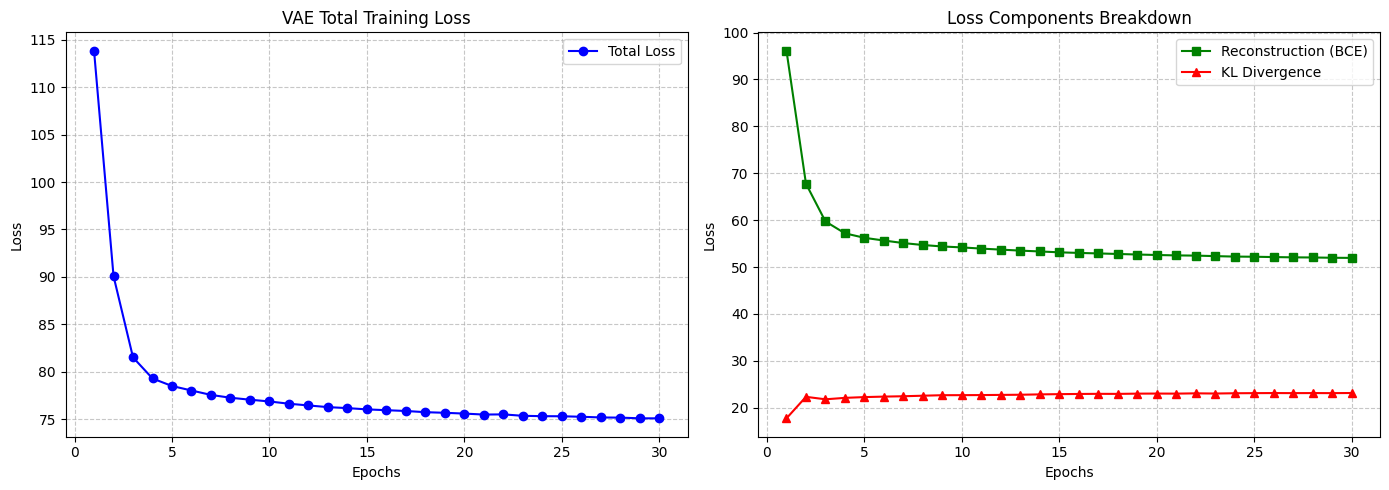

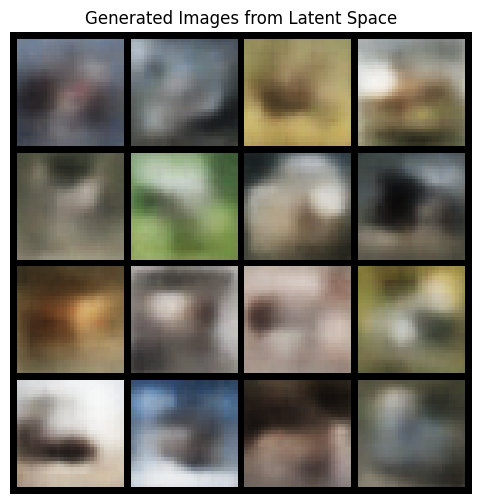

RuntimeError: mat1 and mat2 shapes cannot be multiplied (1x2 and 256x4096)

In [80]:
# Visualize the loss curves
plot_vae_history(cifar_history_amp)

# Generate 16 new CIFAR-10-like images
generate_vae_images(model=vae_net_cifar, num_images=16, device=device)

# Visualize the 2D latent space directly
# plot_2d_latent_space(model=vae_net, test_loader=mnist_test, device=device)

plot_latent_space(vae_net_cifar)